## Different reference Atlas with Salience Network

- Yeo 17 or Gordon 17?
-->  Network Correspondence Toolbox (NCT) 
documentation (all available atlases): https://rubykong.github.io/cbig_network_correspondence/

- dont even need toolbox, just the data saved in `/mnt_04/cbig_network_correspondence_data/atlases` (which is saved there though by installing toolbox and initializing it upon importing it)

In [1]:
import os
import os.path as op
from scipy.io import loadmat
import nibabel as nib
import numpy as np

atlas_dir = '/mnt_04/cbig_network_correspondence_data/atlases'


In [ ]:
atlas_name = 'Yeo_17'

space = 'fsaverage6'
team= 'YeoLab'
atlas = loadmat( op.join(atlas_dir, space, team, 'TY17.mat'))

# colormap for the 17-network parcellation
from matplotlib.colors import ListedColormap
from hcp_utils import hcp
rgb = np.array(list(hcp.yeo17['rgba'].values())[1:])
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_17nets = ListedColormap( np.vstack([grey, rgb]))

In [2]:
atlas_name = 'Gordon_17'

space = 'fs_LR_32k'
team = 'WashU' # os.listdir(op.join(atlas_dir, space, 'WashU'))
atlas= loadmat(op.join(atlas_dir, space, team, 'EG17.mat')) # Evan Gordon 17-network atlas

In [ ]:
import nibabel as nib
from neuromaps import transforms

gifti_fsav6_lh = nib.gifti.GiftiDataArray(data=atlas["lh_labels"].flatten())
gifti_fsav6_lh = nib.GiftiImage(darrays=[gifti_fsav6_lh])

gifti_fsav6_rh = nib.gifti.GiftiDataArray(data=atlas["rh_labels"].flatten())
gifti_fsav6_rh = nib.GiftiImage(darrays=[gifti_fsav6_rh])

if atlas_name == 'Yeo_17':
    labels_fsaverage5_lh = transforms.fsaverage_to_fsaverage(gifti_fsav6_lh, target_density='10k', hemi='L', method = 'nearest')[0] # Specify ‘nearest’ if data are label images.
    labels_fsaverage5_rh = transforms.fsaverage_to_fsaverage(gifti_fsav6_rh, target_density='10k', hemi='R', method = 'nearest')[0] # Specify ‘nearest’ if data are label images.
elif atlas_name == 'Gordon_17':
    labels_fsaverage5_lh = transforms.fslr_to_fsaverage(gifti_fsav6_lh, target_density='10k', hemi='L', method = 'nearest')[0] # Specify ‘nearest’ if data are label images.
    labels_fsaverage5_rh = transforms.fslr_to_fsaverage(gifti_fsav6_rh, target_density='10k', hemi='R', method = 'nearest')[0] # Specify ‘nearest’ if data are label images.

In [ ]:
# save to use as reference
target_dir= f'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/netAtlas_{atlas_name}'
nib.save(labels_fsaverage5_lh, op.join(target_dir, f'netLabels_atlas-{atlas_name}_fsaverage5_lh.func.gii'))
nib.save(labels_fsaverage5_rh, op.join(target_dir, f'netLabels_atlas-{atlas_name}_fsaverage5_rh.func.gii'))



In [ ]:
# save to numpy array
labels_bothHemis = np.concatenate([labels_fsaverage5_lh.agg_data(), labels_fsaverage5_rh.agg_data()])
fn = op.join(target_dir, f'netLabels_atlas-{atlas_name}_fsaverage5_bothHemis.npy')
np.save(fn, labels_bothHemis)

In [3]:
# load in
atlas_name = 'Gordon_17'
target_dir= f'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/netAtlas_{atlas_name}'

labels_fsaverage5_lh = nib.load(op.join(target_dir, f'netLabels_atlas-{atlas_name}_fsaverage5_lh.func.gii'))
labels_fsaverage5_rh = nib.load(op.join(target_dir, f'netLabels_atlas-{atlas_name}_fsaverage5_rh.func.gii'))

In [4]:
hemi_to_plot ='L'
modules_fsav5_hemi = labels_fsaverage5_lh.agg_data() if hemi_to_plot == 'L' else labels_fsaverage5_rh.agg_data()


In [5]:
np.unique(modules_fsav5_hemi)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.], dtype=float32)

Text(0.5, 0.9, 'Gordon_17')

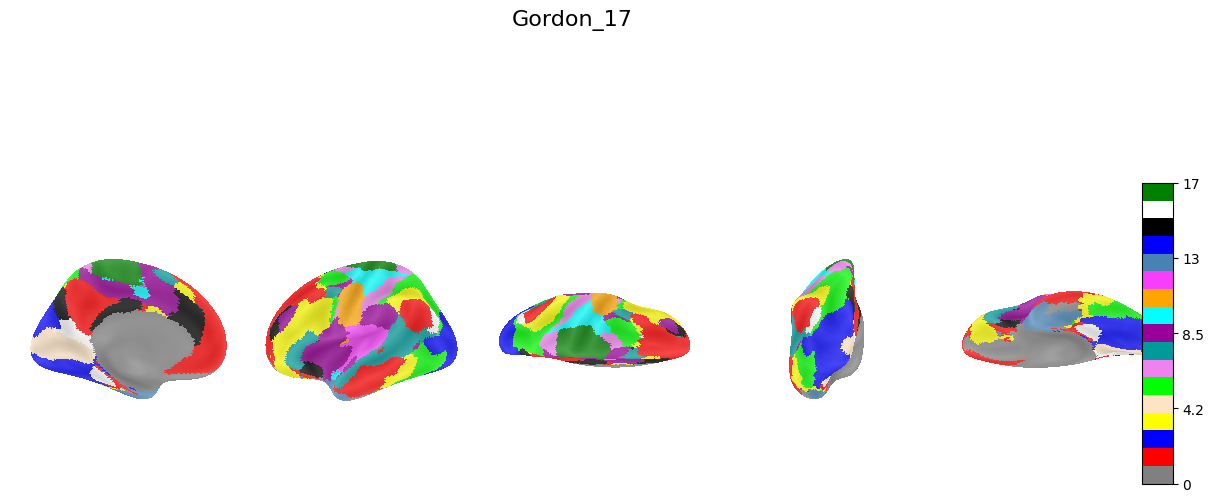

In [20]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
import numpy as np
import os.path as op

import matplotlib.patches as mpatches
import hcp_utils as hcp
import matplotlib.pyplot as plt


fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior', 'ventral']

from utils import get_Gordon17_cmap
cmap = custom_color_map #get_Gordon17_cmap()

i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  

surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'ventral' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= modules_fsav5_hemi, avg_method = 'median',# infl_right # pial_right
            view= view, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            cmap=cmap,vmin = 0, vmax=17,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)
figure.suptitle(f'{atlas_name}', fontsize=16, y=0.9)

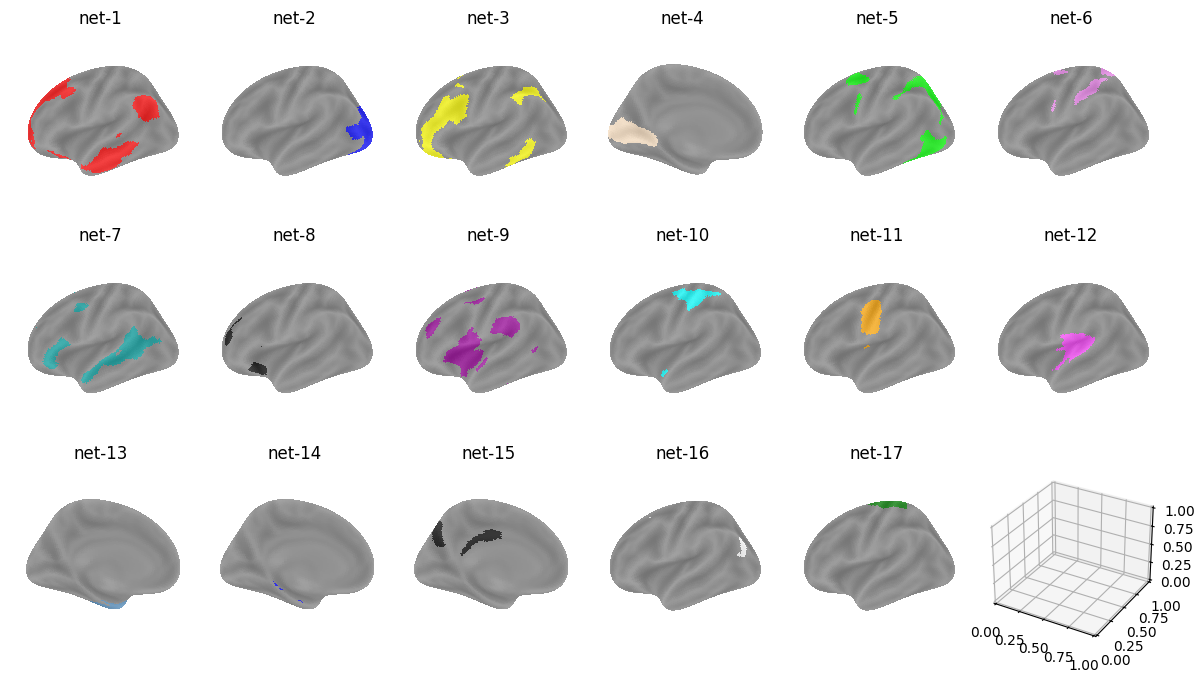

In [21]:
n_nets = 17
view = 'lateral'

modules_fsav5_hemi = labels_fsaverage5_lh.agg_data().astype(int)

figure, axes = plt.subplots(nrows=3, ncols=6,figsize = (15,8), subplot_kw=dict(projection='3d'))
for i in range(n_nets):
    i_net = i + 1
    net_map = modules_fsav5_hemi.copy()
    net_map[net_map != i_net] = 0
    view = 'medial' if i_net in [4,13, 14,15] else 'lateral'
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map=net_map, avg_method = 'median',# infl_right # pial_right
            view= view, colorbar=False, title=f'net-{i_net}',
             # cmap=[custom_color_map[i_net]],
            cmap=custom_color_map,vmin = 0, vmax=17,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes.flatten()[i]) 
figure.subplots_adjust(wspace=0.01)

## Fit average network with Gordon17 as reference

In [23]:
# sub-average
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
sub = 'average'
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
confspec = '36Pscrub3BPfilter'
cm_file = op.join(source_folder,f'cm_av_ses-1_fsav5_unfiltered_confspec-{confspec}runFD104.npy')
cm_f = np.load(cm_file)


In [24]:
from fit_assign_consens_plot_nets import threshold_matrix, spatial_filtering, assign_subject_communities_to_reference, get_consensus_assignment
from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

cm_filtered = spatial_filtering(cm_f, bids_folder=bids_folder)

fn_target_labels_EG17 = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/netAtlas_Gordon_17/netLabels_atlas-Gordon_17_fsaverage5_bothHemis.npy'
target_labels_EG17 = np.load(fn_target_labels_EG17)
target_labels_EG17 = target_labels_EG17[mask]

In [ ]:
conn_thresholds = [0.03, 0.04, 0.05, 0.1, 0.2, 0.4] 
sub_module_mappings_relabelled = []

In [28]:
for conn_threshold in conn_thresholds:
    conn_threshold = conn_thresholds[0]

    cm_thresh = threshold_matrix(cm_filtered, proportion=conn_threshold)
    N = cm_thresh.shape[0]

    from infomap import Infomap
    im = Infomap(preferred_number_of_modules=None) # add flags like '--two-level' if needed
    for i in range(N):
        for j in range(i+1, N):
            w = cm_thresh[i, j]
            if w > 0:
                im.add_link(i, j, w)
    im.run()

    returned_nodes = np.array([node.node_id for node in im.nodes])
    returned_modules = np.array([node.module_id for node in im.nodes])
    full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
    full_module_mapping[returned_nodes] = returned_modules

    relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_EG17,  jaccard_threshold=0.1)
    sub_module_mappings_relabelled.append(relabeled_subject)

  Infomap v2.8.0 starts at 2025-10-27 09:56:13
  -> Input network: 
  -> No file output!
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 16348 nodes and 2359360 links...
  -> One-level codelength: 13.4499122

Trial 1/1 starting at 2025-10-27 09:56:15
Two-level compression: 13% 0.64% 0.00708619748% 0.0279254522% 
Partitioned to codelength 0.563106906 + 11.000361 = 11.56346787 in 54 (52 non-trivial) modules.
Super-level compression: 0.00460985338% to codelength 11.56293481 in 9 top modules.

Recursive sub-structure compression: 9.37912782% 0.280494035% 0% . Found 4 levels with codelength 11.49132288

=> Trial 1/1 finished in 11.4068675s with codelength 11.4913229


Summary after 1 trial
Best end modular solution in 4 levels:
Per level number of module

In [36]:
np.unique(sub_module_mappings_relabelled[5])

array([-1,  1,  9])

In [ ]:

# can happen that small thresholds have very few modules, so we need to check if we have enough
sub_module_mappings_relabelled_sufficient = []
for thresh, mapping in zip(conn_thresholds, sub_module_mappings_relabelled):
    if len(np.unique(mapping)) > 5:  # More than five unique modules for smal thresholds
        sub_module_mappings_relabelled_sufficient.append(mapping)
    else:
        print(f'Skipping mapping with from threshold {thresh}')

consensus_labels = get_consensus_assignment(sub_module_mappings_relabelled_sufficient)
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

In [ ]:
conn_threshold = 0.03
preferred_number_of_modules = 17

cm_thresh = threshold_matrix(cm_filtered, proportion=conn_threshold)
N = cm_thresh.shape[0]

from infomap import Infomap
im = Infomap(preferred_number_of_modules=preferred_number_of_modules) # add flags like '--two-level' if needed
for i in range(N):
    for j in range(i+1, N):
        w = cm_thresh[i, j]
        if w > 0:
            im.add_link(i, j, w)
im.run()

returned_nodes = np.array([node.node_id for node in im.nodes])
returned_modules = np.array([node.module_id for node in im.nodes])
full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
full_module_mapping[returned_nodes] = returned_modules

relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_EG17,  jaccard_threshold=0.1)

modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = relabeled_subject

Text(0.5, 0.9, 'conn-thresh=0.05, N-modules=17')

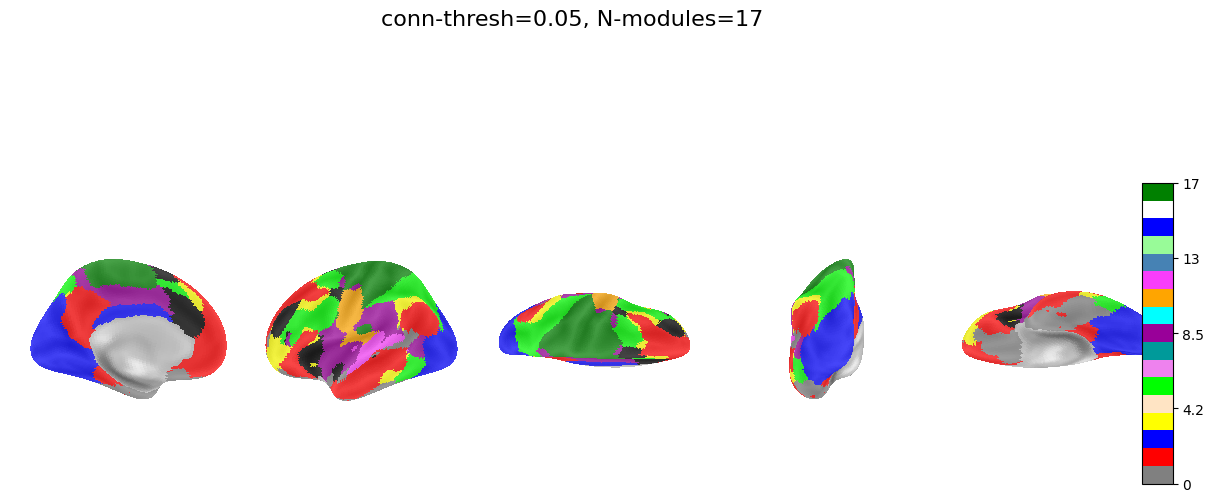

In [ ]:
cmap = custom_color_map #get_Gordon17_cmap()

modules_fsav5_hemi = np.split(modules_fsav5,2)[i_hemi_to_plot]
figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'ventral' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= modules_fsav5_hemi, avg_method = 'median',# infl_right # pial_right
            view= view, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            cmap=cmap,vmin = 0, vmax=17,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)
figure.suptitle(f'conn-thresh={conn_threshold}, N-modules={preferred_number_of_modules}', fontsize=16, y=0.9)

In [ ]:

consensus_labels = get_consensus_assignment(sub_module_mappings_relabelled_sufficient)
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

## Figure out the colormap


In [41]:
import matplotlib.colors as mcolors
import matplotlib.colors as mcolors
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity

custom_color_map = ListedColormap(np.vstack([grey, # 0: background
                                             rgb[8], # 1: DMN
                                             rgb[0], # 2: visual2
                                             rgb[6], # 3: fronto parietal
                                             mcolors.to_rgba('bisque'), #  4: visual 2
                                             rgb[4],  # 5: dorsal attention
                                             mcolors.to_rgba(mcolors.CSS4_COLORS['violet']),# 6: premotor
                                             rgb[5], # 7 : language
                                             mcolors.to_rgba('black'), # 8: salience
                                             rgb[3], # 9: Cingulo opercular
                                             rgb[2],# 10: motor - hand
                                             mcolors.to_rgba(mcolors.CSS4_COLORS['orange']),  # 11: motor - mouth
                                             rgb[7],# 12: auditory 
                                             mcolors.to_rgba('steelblue'), # 13: anterior MTL ?
                                            mcolors.to_rgba('palegreen'), # 14: posterior MTL
                                            mcolors.to_rgba('blue'), # 15: par memory
                                            mcolors.to_rgba('white'), # 16: context
                                            mcolors.to_rgba(mcolors.CSS4_COLORS['green']) # 17: motor - foot
                                             ])) 


In [ ]:
import matplotlib.patches as mpatches
import hcp_utils as hcp
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
cmap_ca = ListedColormap(rgb)

legend_patches = [mpatches.Patch(color=cmap_ca(i), label=f'position {i}')  for i in range(12)]

# Plot the custom legend
plt.figure(figsize=(6, 4))
plt.legend(handles=legend_patches, title="Networks", loc="center")

In [47]:
import math

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

In [49]:
mcolors.CSS4_COLORS

{'aliceblue': '#F0F8FF',
 'antiquewhite': '#FAEBD7',
 'aqua': '#00FFFF',
 'aquamarine': '#7FFFD4',
 'azure': '#F0FFFF',
 'beige': '#F5F5DC',
 'bisque': '#FFE4C4',
 'black': '#000000',
 'blanchedalmond': '#FFEBCD',
 'blue': '#0000FF',
 'blueviolet': '#8A2BE2',
 'brown': '#A52A2A',
 'burlywood': '#DEB887',
 'cadetblue': '#5F9EA0',
 'chartreuse': '#7FFF00',
 'chocolate': '#D2691E',
 'coral': '#FF7F50',
 'cornflowerblue': '#6495ED',
 'cornsilk': '#FFF8DC',
 'crimson': '#DC143C',
 'cyan': '#00FFFF',
 'darkblue': '#00008B',
 'darkcyan': '#008B8B',
 'darkgoldenrod': '#B8860B',
 'darkgray': '#A9A9A9',
 'darkgreen': '#006400',
 'darkgrey': '#A9A9A9',
 'darkkhaki': '#BDB76B',
 'darkmagenta': '#8B008B',
 'darkolivegreen': '#556B2F',
 'darkorange': '#FF8C00',
 'darkorchid': '#9932CC',
 'darkred': '#8B0000',
 'darksalmon': '#E9967A',
 'darkseagreen': '#8FBC8F',
 'darkslateblue': '#483D8B',
 'darkslategray': '#2F4F4F',
 'darkslategrey': '#2F4F4F',
 'darkturquoise': '#00CED1',
 'darkviolet': '#9400D3

(0.9333333333333333, 0.5098039215686274, 0.9333333333333333)

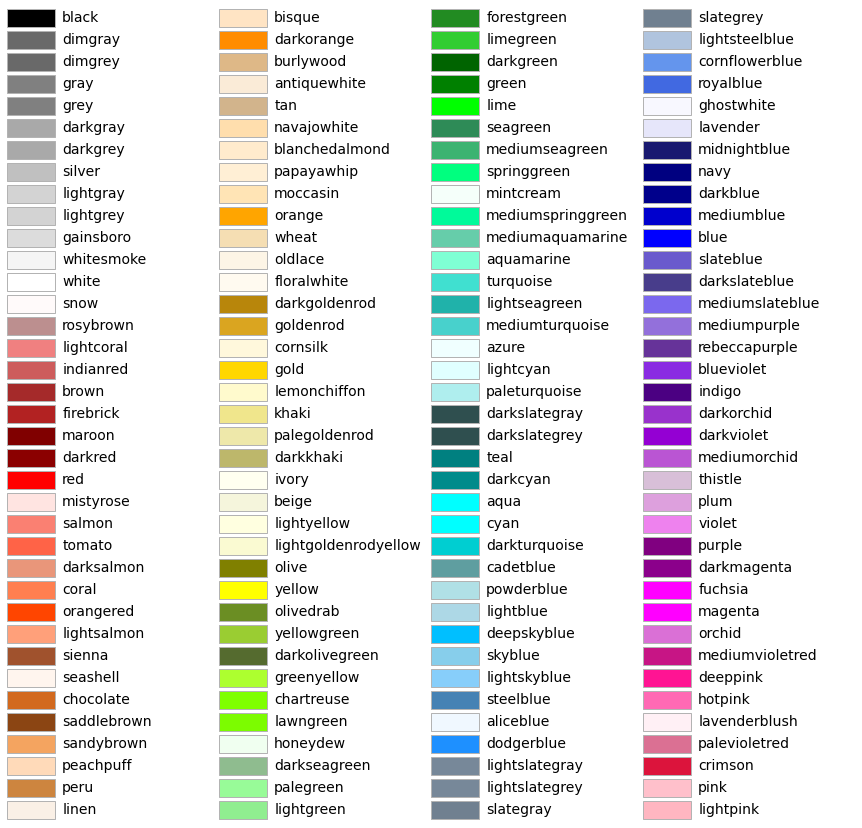

In [53]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

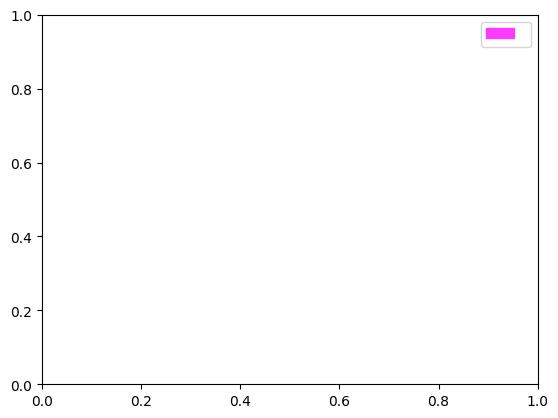

In [ ]:

patch = mpatches.Patch(color=)
plt.figure()
plt.legend(handles=[patch])

In [ ]:
import os
data_dir = os.getenv('CBIG_NETWORK_CORRESPONDENCE_DATA') # or hardcode it!
print(f"Current data directory is: {data_dir}")

import cbig_network_correspondence as cnc

when installing toolbox, before importing it for the first time:
--> put in `/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/cbig_network_correspondence/__init__.py` 
data_dir = os.environ.get("CBIG_NETWORK_CORRESPONDENCE_DATA", os.path.join(os.path.dirname(__file__), 'data'))
 so that it wont save all the data in ~/... where there is limited space!